<a href="https://colab.research.google.com/github/Pam-Pam29/Summative-Assignment---Mission-Based-Reinforcement-Learning/blob/main/notebooks/fakunle_victoria_rl_reinforce.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Sista Health RL — REINFORCE (Policy Gradient)
**Victoria Fakunle | ALU 2026**

This notebook trains a REINFORCE agent on the Sista Health environment and runs 10 hyperparameter experiments.

**REINFORCE** is a Monte Carlo policy gradient method. It learns by observing complete episodes and updating the policy based on total return.

**Environment:** A Nigerian woman sends a maternal/sexual health query. The agent decides the best response strategy.

## Step 1 — Install Libraries

In [1]:
!pip install gymnasium stable-baselines3 numpy pandas matplotlib -q
print(' Libraries installed!')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 188.0/188.0 kB 13.4 MB/s eta 0:00:00
 Libraries installed!


## Step 2 — Define Sista Health Environment

In [7]:
import gymnasium as gym
import numpy as np
from gymnasium import spaces

class SistaHealthEnv(gym.Env):
 TOPICS = ['FGM Complications','VVF Causes','Cultural Barriers',
 'Early Marriage','TBA Dangers','Contraception',
 'STIs & HIV','Antenatal Care','Postpartum Care']
 LANGUAGES = ['English','Yoruba','Pidgin']
 DOMAINS = ['Sexual Health','Maternal Health']
 ACTIONS = ['Text Response','Voice Note','Emergency Referral','Clarify']

 def __init__(self):
  super().__init__()
  self.observation_space = spaces.Box(
  low=np.array([0,0,0,0,0,0], dtype=np.float32),
  high=np.array([2,1,8,1,2,9], dtype=np.float32),
  dtype=np.float32
  )
  self.action_space = spaces.Discrete(4)
  self.state = None
  self.step_count = 0
  self.episode_reward = 0
  self.last_action = None
  self.last_reward = 0
  self.last_feedback = ''

 def _get_obs(self): return self.state.astype(np.float32)

 def _get_info(self):
  return {
  'language': self.LANGUAGES[int(self.state[0])],
  'domain': self.DOMAINS[int(self.state[1])],
  'topic': self.TOPICS[int(self.state[2])],
  'urgency': 'Emergency' if self.state[3]==1 else 'Normal',
  'literacy': ['Low','Medium','High'][int(self.state[4])],
  'episode_reward': self.episode_reward
  }

 def reset(self, seed=None, options=None):
  super().reset(seed=seed)
  self.state = np.array([
  self.np_random.integers(0,3), self.np_random.integers(0,2),
  self.np_random.integers(0,9), 1 if self.np_random.random()<0.2 else 0,
  self.np_random.integers(0,3), 0
  ], dtype=np.float32)
  self.step_count=0; self.episode_reward=0
  self.last_action=None; self.last_reward=0; self.last_feedback='New session'
  return self._get_obs(), self._get_info()

 def step(self, action):
  urgency=int(self.state[3]); literacy=int(self.state[4]); language=int(self.state[0])
  reward=0; terminated=False; feedback=''
  if action==2:
   if urgency==1: reward+=10; feedback='Emergency escalated! +10'; terminated=True
   else: reward-=3; feedback='Unnecessary emergency. -3'
  elif action==0:
   if urgency==1: reward-=10; feedback='Emergency missed! -10'
   elif literacy==2: reward+=5; feedback='Text great. +5'
   elif literacy==1: reward+=2; feedback='Text ok. +2'
   else: reward-=2; feedback='Text poor for low literacy. -2'
  elif action==1:
   if urgency==1: reward-=10; feedback='Emergency missed! -10'
   elif literacy==0: reward+=10; feedback='Voice perfect! +10'
   elif literacy==1: reward+=5; feedback='Voice good. +5'
   else: reward+=1; feedback='Voice ok. +1'
  if language==2: reward+=1; feedback+=' (Pidgin +1)'
  elif action==3:
   if urgency==1: reward-=2; feedback='No clarify in emergency! -2'
   else: reward+=1; feedback='Clarification. +1'
  self.state[5]=min(self.state[5]+1,9); self.step_count+=1
  self.last_action=action; self.last_reward=reward
  self.last_feedback=feedback; self.episode_reward+=reward
  if self.step_count>=10: terminated=True
  return self._get_obs(), reward, terminated, False, self._get_info()

 def render(self): pass
 def close(self): pass

env = SistaHealthEnv()
obs, info = env.reset(seed=42)
print(' Environment created!')
print(f' User: {info["language"]} | {info["domain"]} | Urgency: {info["urgency"]} | Literacy: {info["literacy"]}')

 Environment created!
 User: English | Maternal Health | Urgency: Normal | Literacy: Medium


## Step 3 — Define Callback & Evaluate Function

In [9]:
import os, pandas as pd, matplotlib.pyplot as plt, matplotlib
import seaborn as sns
matplotlib.rcParams['figure.dpi'] = 120
sns.set(style='darkgrid')
from stable_baselines3 import A2C
from stable_baselines3.common.callbacks import BaseCallback
from stable_baselines3.common.monitor import Monitor
os.makedirs('models/pg', exist_ok=True)
os.makedirs('results', exist_ok=True)

class RewardCallback(BaseCallback):
 def __init__(self):
  super().__init__()
  self.rewards_per_episode = []
  self.steps_per_episode = []
  self._cur_rewards = []
  self._cur_steps = 0
 def _on_step(self):
  self._cur_rewards.append(self.locals['rewards'][0])
  self._cur_steps += 1
  if self.locals['dones'][0]:
   self.rewards_per_episode.append(sum(self._cur_rewards))
   self.steps_per_episode.append(self._cur_steps)
   self._cur_rewards=[]; self._cur_steps=0
  return True

def evaluate_model(model, n=20):
 env = SistaHealthEnv()
 rewards = []
 for _ in range(n):
  obs, _ = env.reset()
  ep_r, done = 0, False
  while not done:
   a, _ = model.predict(obs, deterministic=True)
   obs, r, term, trunc, _ = env.step(int(a))
   ep_r += r; done = term or trunc
  rewards.append(ep_r)
 env.close()
 return np.mean(rewards), np.std(rewards)

print(' Ready!')

 Ready!


Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


## Step 4 — REINFORCE Hyperparameter Experiments (10 Runs)
REINFORCE is implemented as A2C with `vf_coef=0` — removing the value function makes it pure policy gradient.

In [11]:
TIMESTEPS = 50000

EXPERIMENTS = [
 {'learning_rate':7e-4, 'gamma':0.99, 'n_steps':10, 'ent_coef':0.01, 'vf_coef':0.0},
 {'learning_rate':1e-3, 'gamma':0.99, 'n_steps':10, 'ent_coef':0.01, 'vf_coef':0.0},
 {'learning_rate':5e-4, 'gamma':0.99, 'n_steps':10, 'ent_coef':0.01, 'vf_coef':0.0},
 {'learning_rate':7e-4, 'gamma':0.95, 'n_steps':10, 'ent_coef':0.01, 'vf_coef':0.0},
 {'learning_rate':7e-4, 'gamma':0.90, 'n_steps':10, 'ent_coef':0.01, 'vf_coef':0.0},
 {'learning_rate':7e-4, 'gamma':0.99, 'n_steps':20, 'ent_coef':0.01, 'vf_coef':0.0},
 {'learning_rate':7e-4, 'gamma':0.99, 'n_steps':5, 'ent_coef':0.01, 'vf_coef':0.0},
 {'learning_rate':7e-4, 'gamma':0.99, 'n_steps':10, 'ent_coef':0.05, 'vf_coef':0.0},
 {'learning_rate':7e-4, 'gamma':0.99, 'n_steps':10, 'ent_coef':0.00, 'vf_coef':0.0},
 {'learning_rate':7e-4, 'gamma':0.99, 'n_steps':10, 'ent_coef':0.01, 'vf_coef':0.25},
]

results, callbacks = [], []

for i, p in enumerate(EXPERIMENTS):
 print(f'[Run {i+1}/10] lr={p["learning_rate"]} | gamma={p["gamma"]} | '
 f'n_steps={p["n_steps"]} | ent={p["ent_coef"]} | vf_coef={p["vf_coef"]}')
 env = Monitor(SistaHealthEnv())
 cb = RewardCallback()
 # vf_coef=0 removes value function → pure REINFORCE policy gradient
 model = A2C('MlpPolicy', env,
 learning_rate=p['learning_rate'], gamma=p['gamma'],
 n_steps=p['n_steps'], ent_coef=p['ent_coef'],
 vf_coef=p['vf_coef'], verbose=0)
 model.learn(total_timesteps=TIMESTEPS, callback=cb)
 mean_r, std_r = evaluate_model(model)
 print(f' → Mean Reward: {mean_r:.2f} ± {std_r:.2f}')
 if not results or mean_r > max(r['mean_r'] for r in results):
  model.save('models/pg/best_reinforce_model')
  print(' → New best! Model saved.')
 results.append({'Run':i+1,'Learning Rate':p['learning_rate'],'Gamma':p['gamma'],
 'N Steps':p['n_steps'],'Entropy Coef':p['ent_coef'],'VF Coef':p['vf_coef'],
 'mean_r':mean_r,'Mean Reward':round(mean_r,2),'Std Reward':round(std_r,2)})
 callbacks.append(cb)
 env.close()

print('\n All 10 REINFORCE experiments complete!')

[Run 1/10] lr=0.0007 | gamma=0.99 | n_steps=10 | ent=0.01 | vf_coef=0.0


/usr/local/lib/python3.12/dist-packages/stable_baselines3/common/on_policy_algorithm.py:150: UserWarning: You are trying to run A2C on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


 → Mean Reward: 42.15 ± 36.15
 → New best! Model saved.
[Run 2/10] lr=0.001 | gamma=0.99 | n_steps=10 | ent=0.01 | vf_coef=0.0
 → Mean Reward: 46.70 ± 44.25
 → New best! Model saved.
[Run 3/10] lr=0.0005 | gamma=0.99 | n_steps=10 | ent=0.01 | vf_coef=0.0
 → Mean Reward: 49.50 ± 36.26
 → New best! Model saved.
[Run 4/10] lr=0.0007 | gamma=0.95 | n_steps=10 | ent=0.01 | vf_coef=0.0
 → Mean Reward: 59.00 ± 34.91
 → New best! Model saved.
[Run 5/10] lr=0.0007 | gamma=0.9 | n_steps=10 | ent=0.01 | vf_coef=0.0
 → Mean Reward: 30.10 ± 34.29
[Run 6/10] lr=0.0007 | gamma=0.99 | n_steps=20 | ent=0.01 | vf_coef=0.0
 → Mean Reward: 39.05 ± 25.02
[Run 7/10] lr=0.0007 | gamma=0.99 | n_steps=5 | ent=0.01 | vf_coef=0.0
 → Mean Reward: 53.10 ± 39.91
[Run 8/10] lr=0.0007 | gamma=0.99 | n_steps=10 | ent=0.05 | vf_coef=0.0
 → Mean Reward: 41.05 ± 36.14
[Run 9/10] lr=0.0007 | gamma=0.99 | n_steps=10 | ent=0.0 | vf_coef=0.0
 → Mean Reward: 48.10 ± 35.05
[Run 10/10] lr=0.0007 | gamma=0.99 | n_steps=10 | ent=

## Step 5 — Results Table

In [12]:
df = pd.DataFrame(results).drop(columns=['mean_r'])
df.to_csv('results/reinforce_results.csv', index=False)
print('REINFORCE HYPERPARAMETER EXPERIMENT RESULTS')
print('='*75)
print(df.to_string(index=False))
best = df.loc[df['Mean Reward'].idxmax()]
print(f'\n Best Run: #{int(best["Run"])} | Mean Reward: {best["Mean Reward"]}')
print(f' lr={best["Learning Rate"]} | gamma={best["Gamma"]} | n_steps={best["N Steps"]}')

REINFORCE HYPERPARAMETER EXPERIMENT RESULTS
 Run  Learning Rate  Gamma  N Steps  Entropy Coef  VF Coef  Mean Reward  Std Reward
   1         0.0007   0.99       10          0.01     0.00        42.15       36.15
   2         0.0010   0.99       10          0.01     0.00        46.70       44.25
   3         0.0005   0.99       10          0.01     0.00        49.50       36.26
   4         0.0007   0.95       10          0.01     0.00        59.00       34.91
   5         0.0007   0.90       10          0.01     0.00        30.10       34.29
   6         0.0007   0.99       20          0.01     0.00        39.05       25.02
   7         0.0007   0.99        5          0.01     0.00        53.10       39.91
   8         0.0007   0.99       10          0.05     0.00        41.05       36.14
   9         0.0007   0.99       10          0.00     0.00        48.10       35.05
  10         0.0007   0.99       10          0.01     0.25        56.15       31.79

 Best Run: #4 | Mean Reward: 59

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


## Step 6 — Plots

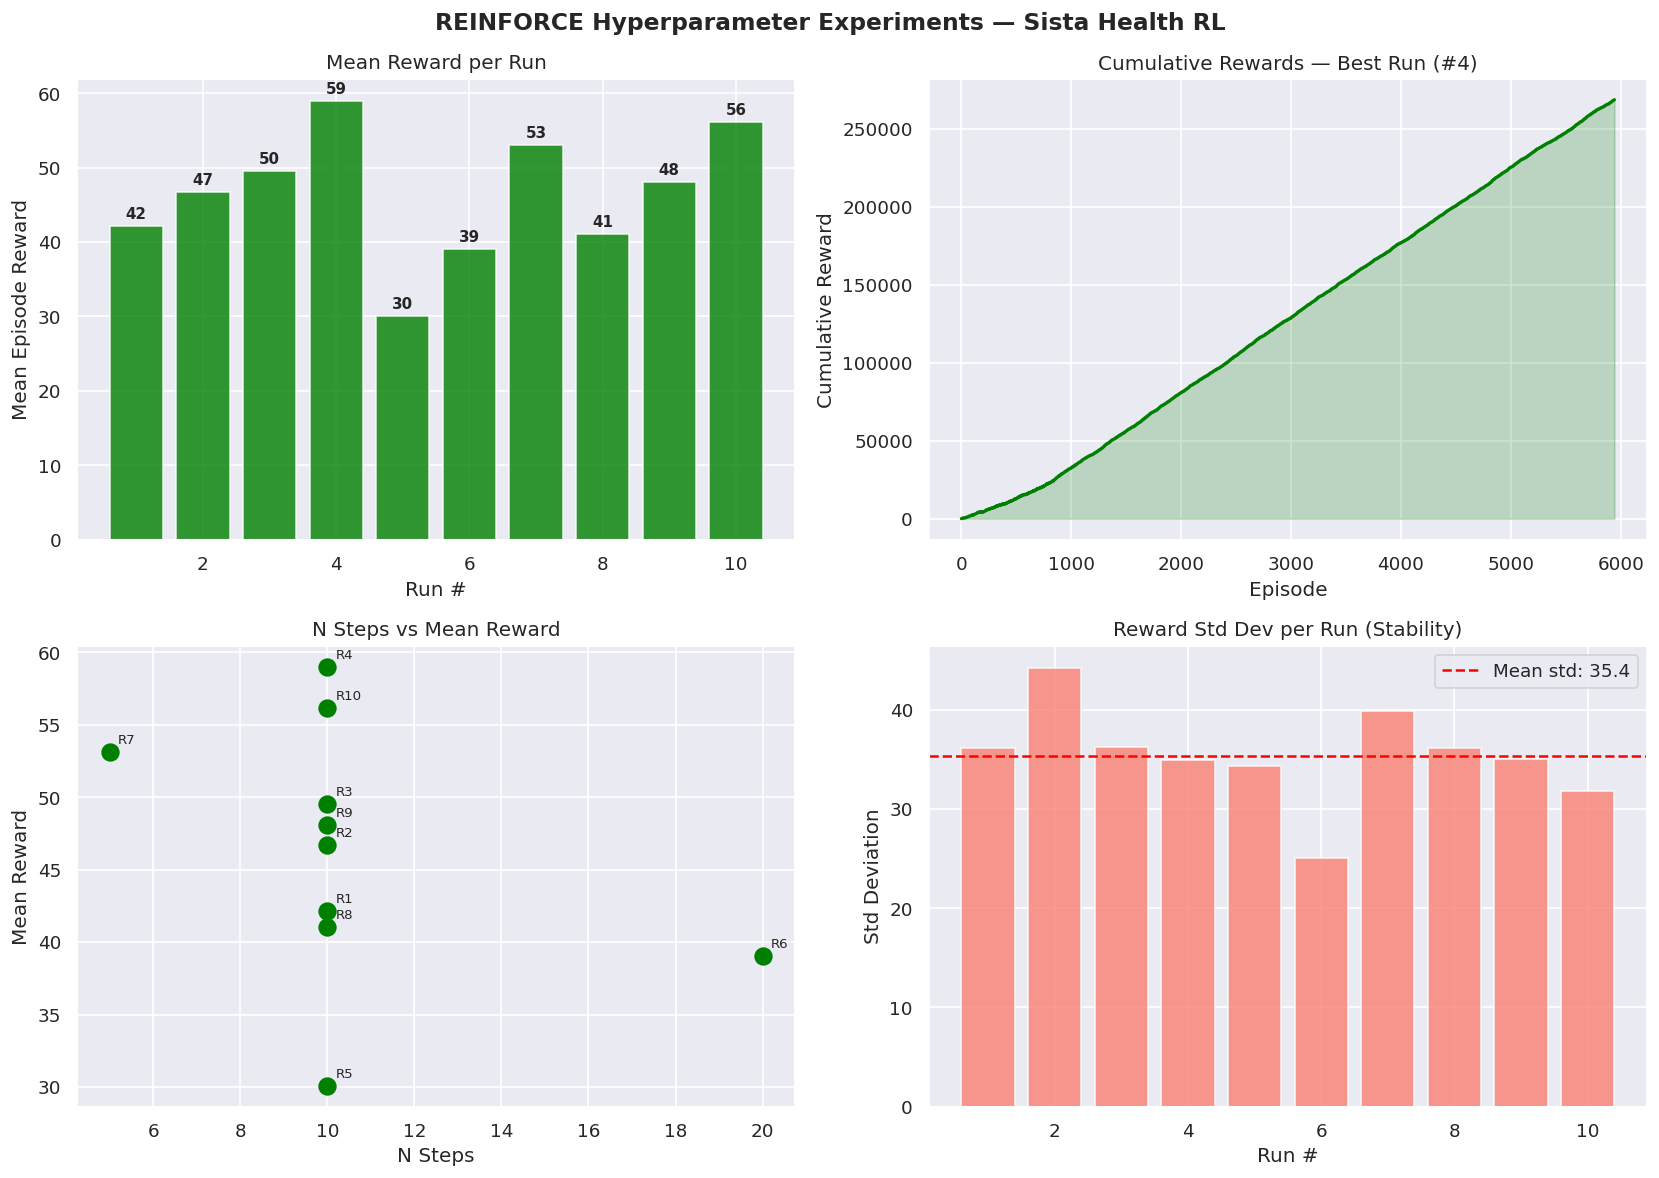

 Saved: results/reinforce_plots.png


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [13]:
best_idx = df['Mean Reward'].idxmax()
best_cb = callbacks[best_idx]
means = df['Mean Reward'].tolist()
runs = df['Run'].tolist()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('REINFORCE Hyperparameter Experiments — Sista Health RL', fontsize=14, fontweight='bold')

# Bar chart
colors = ['green' if m > 0 else 'red' for m in means]
axes[0,0].bar(runs, means, color=colors, alpha=0.8)
axes[0,0].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[0,0].set_title('Mean Reward per Run')
axes[0,0].set_xlabel('Run #'); axes[0,0].set_ylabel('Mean Episode Reward')
for i,v in enumerate(means):
 axes[0,0].text(i+1, v+1, f'{v:.0f}', ha='center', fontsize=9, fontweight='bold')

# Cumulative reward
rewards = best_cb.rewards_per_episode
cumulative = np.cumsum(rewards)
axes[0,1].plot(cumulative, color='green', linewidth=2)
axes[0,1].fill_between(range(len(cumulative)), cumulative, alpha=0.2, color='green')
axes[0,1].set_title(f'Cumulative Rewards — Best Run (#{best_idx+1})')
axes[0,1].set_xlabel('Episode'); axes[0,1].set_ylabel('Cumulative Reward')

# N steps effect
n_steps = df['N Steps'].tolist()
axes[1,0].scatter(n_steps, means, color='green', s=100)
axes[1,0].set_title('N Steps vs Mean Reward')
axes[1,0].set_xlabel('N Steps'); axes[1,0].set_ylabel('Mean Reward')
for i,(x,y) in enumerate(zip(n_steps,means)):
 axes[1,0].annotate(f'R{i+1}',(x,y),textcoords='offset points',xytext=(5,5),fontsize=8)

# Reward variance (stability)
stds = df['Std Reward'].tolist()
axes[1,1].bar(runs, stds, color='salmon', alpha=0.8)
axes[1,1].set_title('Reward Std Dev per Run (Stability)')
axes[1,1].set_xlabel('Run #'); axes[1,1].set_ylabel('Std Deviation')
axes[1,1].axhline(np.mean(stds), color='red', linestyle='--',
 label=f'Mean std: {np.mean(stds):.1f}')
axes[1,1].legend()

plt.tight_layout()
plt.savefig('results/reinforce_plots.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Saved: results/reinforce_plots.png')

## Step 7 — Run Best REINFORCE Agent

In [15]:
best_model = A2C.load('models/pg/best_reinforce_model')
env = SistaHealthEnv()
all_rewards = []
for ep in range(5):
    obs, info = env.reset()
    ep_r, done, step = 0, False, 0
    print(f'\n{"="*55}')
    print(f' EPISODE {ep+1} | {info["language"]} | {info["domain"]} | Urgency: {info["urgency"]} | Literacy: {info["literacy"]}')
    print(f'{"─"*55}')
    while not done:
        action, _ = best_model.predict(obs, deterministic=True)
        obs, r, term, trunc, info = env.step(int(action))
        sign = '' if r>0 else ('' if r==0 else '')
        print(f' Step {step+1:2d} | {env.ACTIONS[int(action)]:20s} | {r:+.0f} {sign}')
        ep_r+=r; step+=1; done=term or trunc
    print(f' Episode Reward: {ep_r:.1f}')
    all_rewards.append(ep_r)
print(f'\n SUMMARY — REINFORCE | Mean: {np.mean(all_rewards):.2f}')
env.close()


 EPISODE 1 | Pidgin | Sexual Health | Urgency: Normal | Literacy: Low
───────────────────────────────────────────────────────
 Step  1 | Voice Note           | +11 
 Step  2 | Voice Note           | +11 
 Step  3 | Voice Note           | +11 
 Step  4 | Voice Note           | +11 
 Step  5 | Voice Note           | +11 
 Step  6 | Voice Note           | +11 
 Step  7 | Voice Note           | +11 
 Step  8 | Voice Note           | +11 
 Step  9 | Voice Note           | +11 
 Step 10 | Voice Note           | +11 
 Episode Reward: 110.0

 EPISODE 2 | Yoruba | Sexual Health | Urgency: Normal | Literacy: High
───────────────────────────────────────────────────────
 Step  1 | Voice Note           | +1 
 Step  2 | Voice Note           | +1 
 Step  3 | Voice Note           | +1 
 Step  4 | Voice Note           | +1 
 Step  5 | Voice Note           | +1 
 Step  6 | Voice Note           | +1 
 Step  7 | Voice Note           | +1 
 Step  8 | Voice Note           | +1 
 Step  9 | Voice Note       

/usr/local/lib/python3.12/dist-packages/stable_baselines3/common/on_policy_algorithm.py:150: UserWarning: You are trying to run A2C on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(


## Step 8 — Download Results

In [17]:
import shutil
from google.colab import files
shutil.make_archive('reinforce_results', 'zip', 'results')
files.download('reinforce_results.zip')
print(' Downloaded!')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

 Downloaded!


In [16]:
from google.colab import drive
drive.mount('/content/drive')

import shutil, os
os.makedirs('/content/drive/MyDrive/sista_health_rl/models/pg', exist_ok=True)
os.makedirs('/content/drive/MyDrive/sista_health_rl/results', exist_ok=True)

shutil.copy('models/pg/best_reinforce_model.zip',
            '/content/drive/MyDrive/sista_health_rl/models/pg/best_reinforce_model.zip')
shutil.copy('results/reinforce_plots.png',
            '/content/drive/MyDrive/sista_health_rl/results/reinforce_plots.png')
shutil.copy('results/reinforce_results.csv',
            '/content/drive/MyDrive/sista_health_rl/results/reinforce_results.csv')

print('REINFORCE saved to Drive!')

Mounted at /content/drive
REINFORCE saved to Drive!
